<a href="https://colab.research.google.com/github/paramita-pp/time-series-analysis/blob/main/Time_Series_Analysis_in_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
%cd /content/drive/MyDrive/Time Series Analysis/Time Series Analysis Practice

/content/drive/MyDrive/Time Series Analysis/Time Series Analysis Practice


In [10]:
# Load Pandas
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

# Lab 1 - Data Loading & Index Prep
- Load the department - sales csv dataset into a dataframe
- Convert the date index to yyyy-mm-dd format
- Set the index frequency to weekly (W-FRI)

In [11]:
# Load the department sales into a df
df = pd.read_csv("department-sales.csv", parse_dates = True, index_col = [0])
df.head()

,Weekly_Sales,IsHoliday
Date,,
05/02/2010,24924.50,False
12/02/2010,46039.49,True
19/02/2010,41595.55,False
26/02/2010,19403.54,False
05/03/2010,21827.90,False


In [12]:
df.index = pd.to_datetime(df.index, format = '%d/%m/%Y')
df.index

DatetimeIndex(['2010-02-05', '2010-02-12', '2010-02-19', '2010-02-26',
               '2010-03-05', '2010-03-12', '2010-03-19', '2010-03-26',
               '2010-04-02', '2010-04-09',
               ...
               '2012-08-24', '2012-08-31', '2012-09-07', '2012-09-14',
               '2012-09-21', '2012-09-28', '2012-10-05', '2012-10-12',
               '2012-10-19', '2012-10-26'],
              dtype='datetime64[ns]', name='Date', length=143, freq=None)

In [13]:
# Set the index Frequency to Weekly
df.index.freq = "W-FRI"
df.index

DatetimeIndex(['2010-02-05', '2010-02-12', '2010-02-19', '2010-02-26',
               '2010-03-05', '2010-03-12', '2010-03-19', '2010-03-26',
               '2010-04-02', '2010-04-09',
               ...
               '2012-08-24', '2012-08-31', '2012-09-07', '2012-09-14',
               '2012-09-21', '2012-09-28', '2012-10-05', '2012-10-12',
               '2012-10-19', '2012-10-26'],
              dtype='datetime64[ns]', name='Date', length=143, freq='W-FRI')

# Lab 2 - Visualization
- Plot weekly sales using the Weekly_Sales column and add a title to the chart
- Highlight holiday weeks with vertical dashed red lines

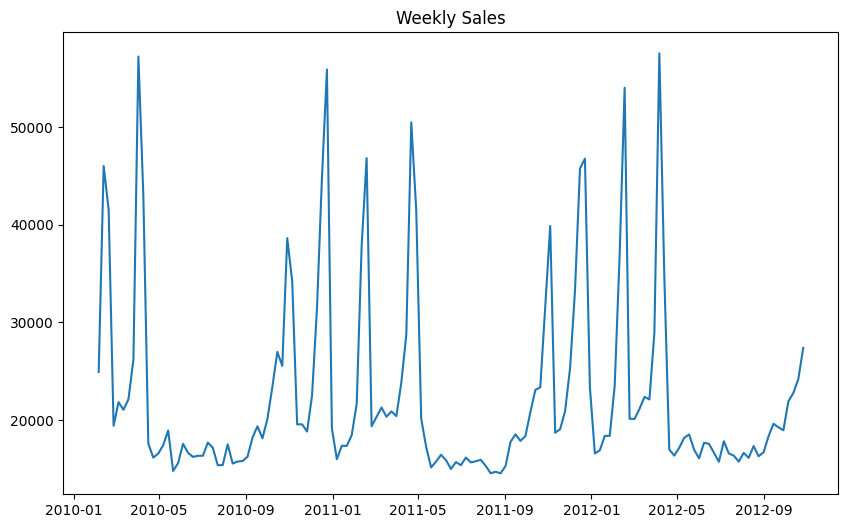

In [14]:
# Plot the weekly sales and add a title
plt.figure(figsize = (10, 6))
plt.plot(df.Weekly_Sales)
plt.title("Weekly Sales")
plt.show()

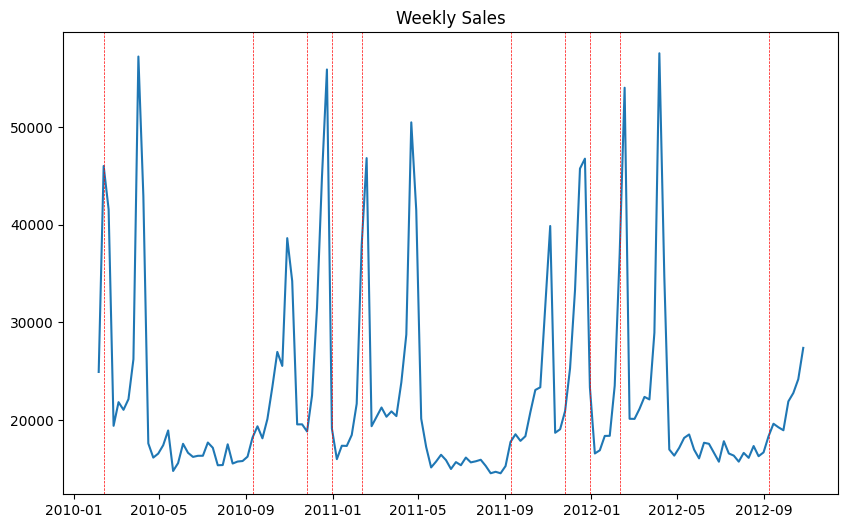

In [17]:
# Plot the weekly sales and add a title
plt.figure(figsize = (10, 6))
plt.plot(df.Weekly_Sales)

for date, row in df.iterrows():
    if row["IsHoliday"]:
        plt.axvline(date, color = "red", linestyle = "--", lw = 0.5)

plt.title("Weekly Sales")
plt.show()

# Lab 3 - ACF, PACF & Decomposition
- Plot the ACF of Weekly_Sales with 60 lags
- Plot the PACF of Weekly_Sales with 60 lags
- Perform multiplicative seasonal decomposition with period = 52

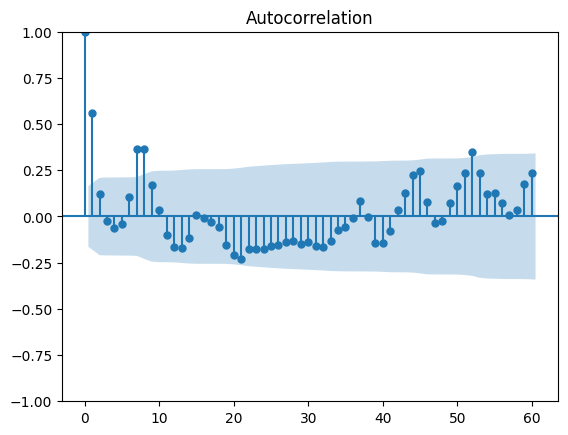

In [18]:
# ACF with 60 lags
plot_acf(df.Weekly_Sales, lags = 60)
plt.show()

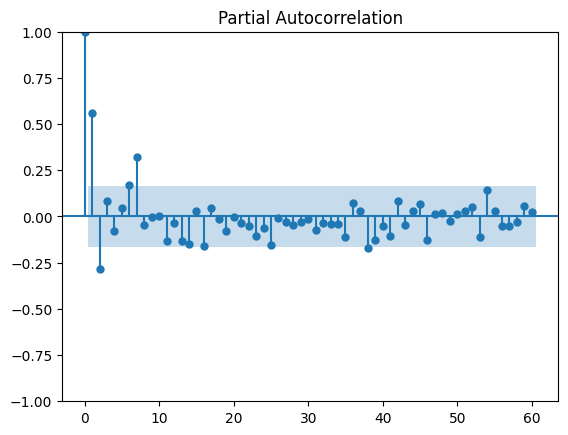

In [19]:
# PACF with 60 lags
plot_pacf(df.Weekly_Sales, lags = 60)
plt.show()

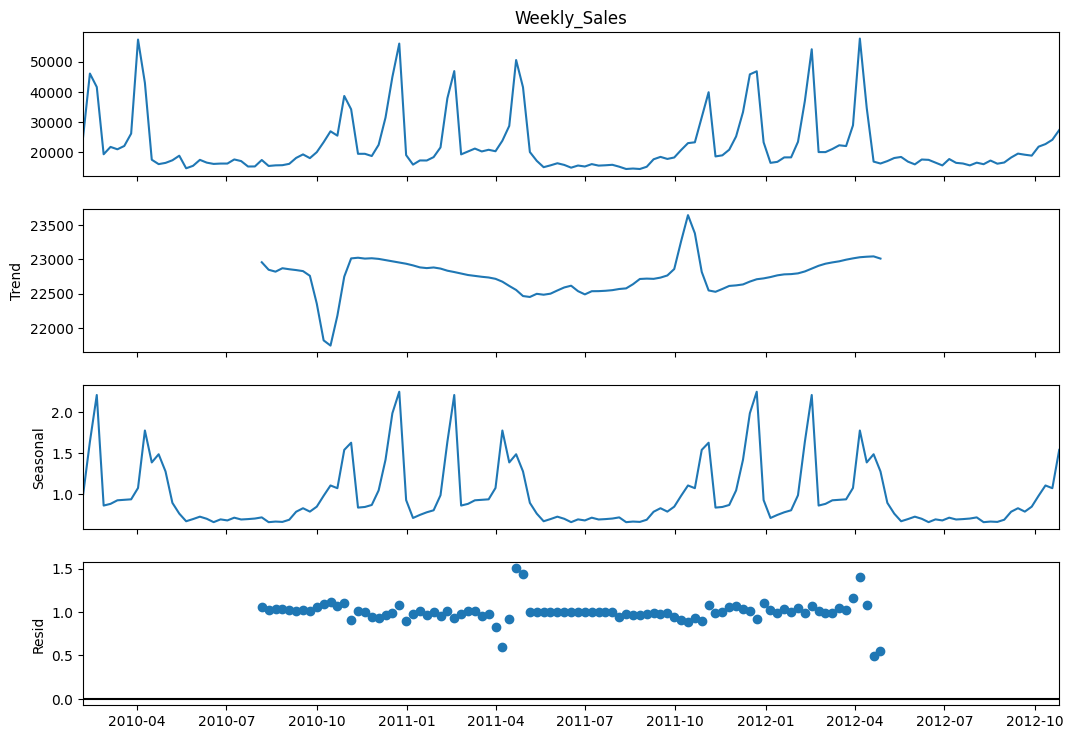

In [23]:
# Seasonal Decomposition
decomposition = seasonal_decompose(df.Weekly_Sales, model = "multiplicative", period = 52)
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()